In [1]:
#Import necessary libraries
import sys
import os
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from pycgp_finalclass.Config import CGPConfig
from pycgp_finalclass.ES import ES
from pycgp_finalclass.Evaluator import EvaluatorSin, Binary_Classifier, Regressor, MultiClassClassifier
from pycgp_finalclass.Node import Node
from pycgp_finalclass.Mutation import Golden_mutation
from pycgp_finalclass.Function import Func
from pycgp_finalclass.Function_library import *
from pycgp_finalclass.Genome import CGPGenome

In [2]:
def build_funcLib(): #Define the function used
    return [Func(f_sum, 'sum', 2, 0), #Put in comments function that are not used
            Func(f_aminus, 'aminus', 2, 0),
            Func(f_mult, 'mult', 2, 0),
            Func(f_exp, 'exp', 2, 0),
            Func(f_abs, 'abs', 1, 0),
            Func(f_sqrt, 'sqrt', 1, 0),
            Func(f_sqrtxy, 'sqrtxy', 2, 0),
            Func(f_squared, 'squared', 1, 0),
            Func(f_pow, 'pow', 2, 0),
            Func(f_one, 'one', 0, 0),
            Func(f_zero, 'zero', 0, 0),
            Func(f_const, 'const', 0, 1),
            #Func(f_inv, 'inv', 1, 0),
            Func(f_gt, 'gt', 2, 0),
            Func(safe_div, 'safe_div', 2, 0),
            #Func(f_asin, 'asin', 1, 0),
            #Func(f_acos, 'acos', 1, 0),
            #Func(f_atan, 'atan', 1, 0),
            #Func(f_sin, 'sin', 1, 0),
            Func(f_min, 'min', 2, 0),
            Func(f_max, 'max', 2, 0)
            #Func(f_round, 'round', 1, 0),
            #Func(f_floor, 'floor', 1, 0),
            #Func(f_ceil, 'ceil', 1, 0)
            ]
functions = build_funcLib()

Starting fitness -5.8759


Gen 1888 | Best: 0.6433: 100%|██████████| 10000/10000 [41:57<00:00,  3.97gen/s]   



Best Train fitness achieved: 0.6433

Test fitness: 0.5975
n4 = min(x2, x3)
n5 = mult(n4, n4)
n6 = sqrt(n4)
n7 = max(n4, x0)
n8 = safe_div(n6, n4)
n9 = pow(n5, x0)
n10 = gt(n8, n5)
n11 = exp(n9, n9)
n12 = gt(x1, n6)
n13 = squared(x0)
n14 = min(n13, n12)
n15 = max(n7, x3)
n16 = max(n4, n12)
n17 = mult(x1, n4)
n18 = pow(n16, n5)
n19 = squared(x2)
n20 = aminus(n10, n9)
n21 = pow(n10, n15)
n22 = const()
n23 = gt(n8, n4)
n24 = one()
n25 = sqrt(n10)
n26 = one()
n27 = sqrtxy(x2, x3)
n28 = mult(n16, n16)
n29 = pow(n5, n19)
n30 = gt(x2, n11)
n31 = const()
n32 = pow(n21, n18)
n33 = safe_div(n31, x1)
Outputs: n20, n9, n11, n20, n32, n29, n26, n31, n20

Unrolled output expression 0:
aminus(gt(safe_div(sqrt(min(x2, x3)), min(x2, x3)), mult(min(x2, x3), min(x2, x3))), pow(mult(min(x2, x3), min(x2, x3)), x0))
Unrolled output expression 1:
pow(mult(min(x2, x3), min(x2, x3)), x0)
Unrolled output expression 2:
exp(pow(mult(min(x2, x3), min(x2, x3)), x0), pow(mult(min(x2, x3), min(x2, x3)), x0))
Unrolled

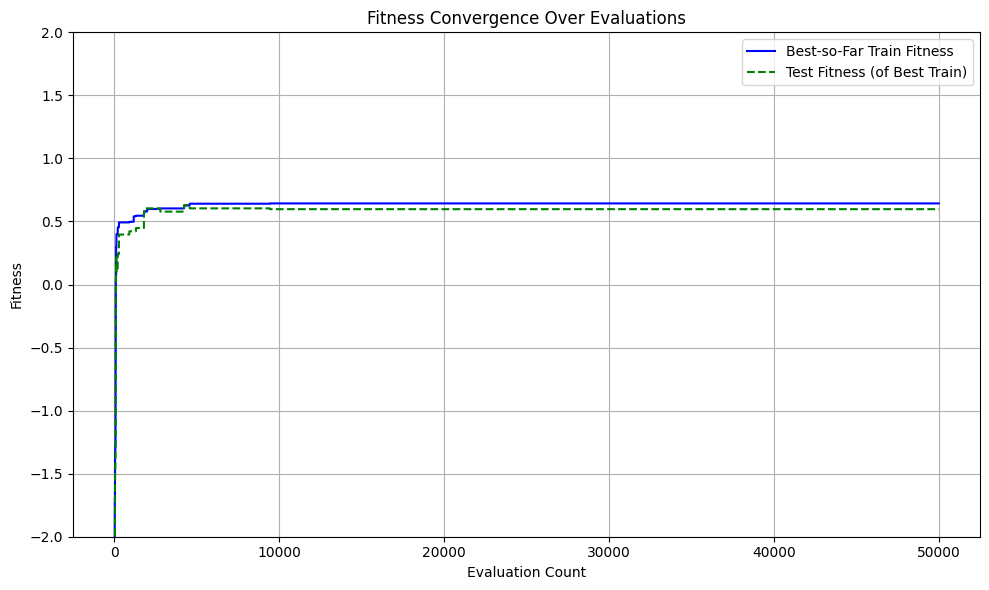

c:\Users\pauls\Bureau\Cours_2IS_M2\stage\pyCGP2.0\pycgp_finalclass\Genome.py:243: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


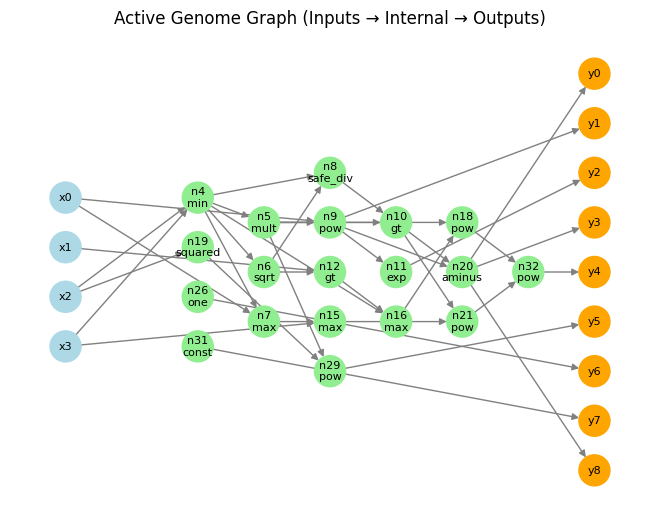

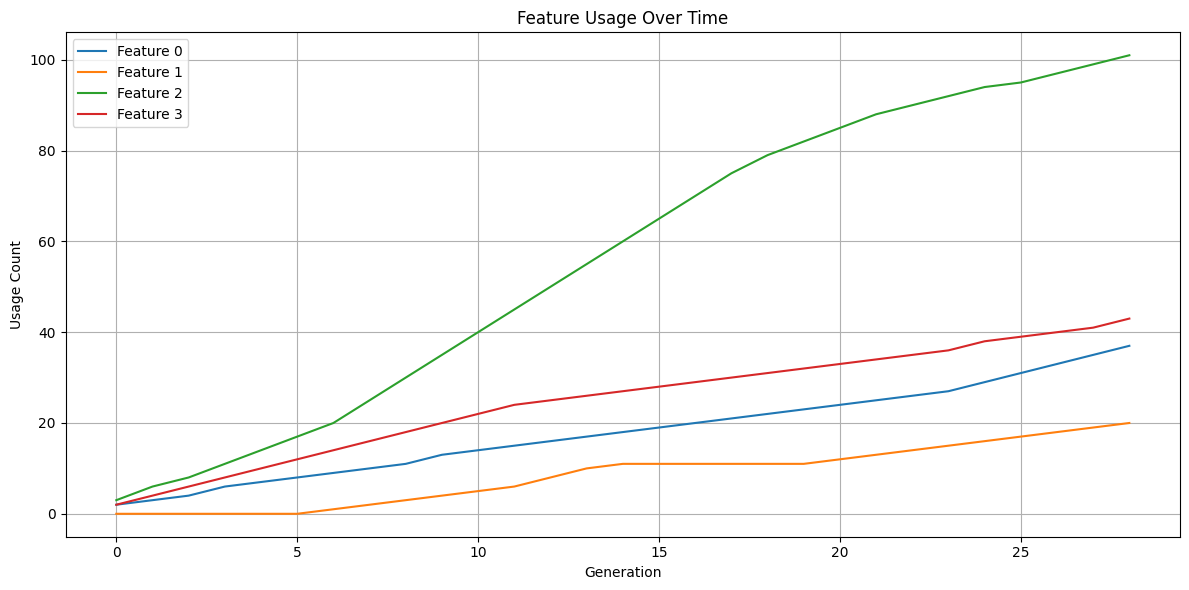

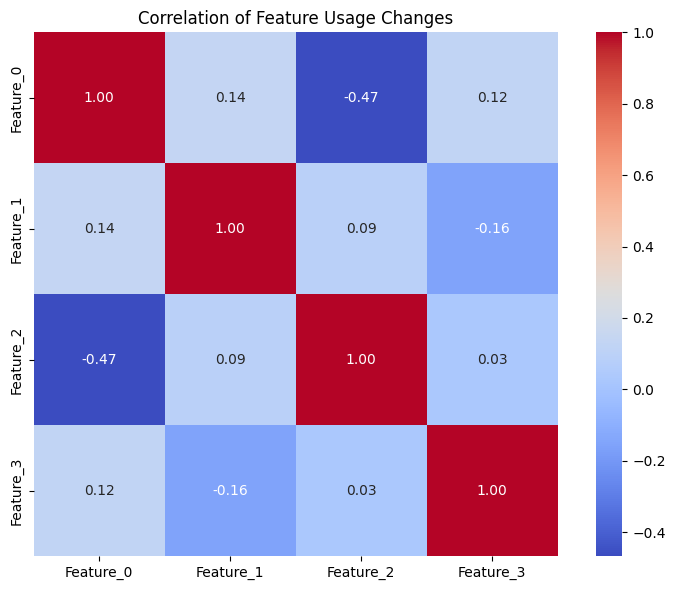

In [3]:
## Initialization of the CGP algorithm for regression ##

from pmlb import fetch_data
from sklearn.preprocessing import MinMaxScaler

# Selection of dataset
# We use a PMLB dataset for regression in this example
# You can change the dataset by modifying the fetch_data function parameters and putting the Dataset ID you want to use
gametes = fetch_data('1027_ESL')
# We save the dataset in a local directory
X, y = fetch_data('1027_ESL', return_X_y=True, local_cache_dir='./datasets')

# Float conversion data
X = X.astype(float)
y = y.astype(float)

# Standardize the data between -1 and 1
# This is important for the CGP algorithm to work properly
scaler = MinMaxScaler(feature_range=(-1, 1))
X = scaler.fit_transform(X)

# Here we define the evaluator for the CGP algorithm
# In this case we use a regression evaluator but you can use a multi-class classifier in the case of classification problems
evaluator = Regressor(X, y)

#Initialise config with the same number of inputs as features in the datasets, internal nodes around 20/30, outputs(number of classes)
CGP_config = CGPConfig(num_inputs=X.shape[1], num_nodes=30, num_outputs=9, input_node_chance=0.4, const_min=-1, const_max=1, function_set=functions)

# Define the mutation operator with the probabilities for each type of mutation
mutationcgp_golden = Golden_mutation(CGP_config,input_node_mutation_rate=0.2, function_mutation_rate=0.4, input_mutation_rate=0.5, const_mutation_rate=0.1,output_node_mutation_rate=0.5)

# Initialize the Evolution strategy with the number of offspring with the lam parameter
ES_cgp = ES(evaluator, lam=5,parent_factory=lambda: CGPGenome.create_genome(CGP_config),mutation = mutationcgp_golden, config= CGP_config)

# Run the ES for a chosen number of generations and early stopping in case of no improvement
# Put verbose=True to see the progress of the evolution
best_genome = ES_cgp.evolve(n_generations=10000, early_stopping=10000, early_switch= 5000 ,project_name= "1027_ESL", verbose=True)

In [ ]:
import pandas as pd
# Load the CSV file
df = pd.read_csv('Results/cgp_results_log_1027_ESL.csv',sep=";")

# Compute the mean of a column (e.g., 'my_column')
mean_value = df['fitness'].mean()
variance_value = df['fitness'].var()

print(f"Mean of 'fitness': {mean_value}")
print(f"Variance of 'fitness': {variance_value}")

In [4]:
## Comparison with other ML models ##
from pmlb import fetch_data
from sklearn.preprocessing import MinMaxScaler

from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
import pandas as pd


# --- Load the dataset ---
X, y = fetch_data('1027_ESL', return_X_y=True, local_cache_dir='./datasets')

# --- Split the dataset ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#Standardize features for models that benefit from it (SVM, KNN, Ridge, etc.) ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# --- Define regression models ---
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(),
    'Random Forest': RandomForestRegressor(random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42),
    'Support Vector Regressor': SVR(),
    'KNN Regressor': KNeighborsRegressor()
}

# --- Evaluate R² for each model ---
results = {}

for name, model in models.items():
    if name in ['Support Vector Regressor', 'KNN Regressor', 'Ridge Regression']:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    results[name] = r2
    print(f"{name}: R² score = {r2:.4f}")

# --- Show sorted results ---
df_results = pd.DataFrame.from_dict(results, orient='index', columns=['R2 Score'])
df_results = df_results.sort_values('R2 Score', ascending=False)
print("\n=== Sorted Results ===")
print(df_results)
print("\n=== CGP result ===")
print(f"CGP: R² score = {mean_value:.4f}")


Linear Regression: R² score = 0.8234
Ridge Regression: R² score = 0.8233
Random Forest: R² score = 0.7418
Gradient Boosting: R² score = 0.8038
Support Vector Regressor: R² score = 0.8075
KNN Regressor: R² score = 0.8001

=== Sorted Results ===
                          R2 Score
Linear Regression         0.823357
Ridge Regression          0.823297
Support Vector Regressor  0.807521
Gradient Boosting         0.803834
KNN Regressor             0.800066
Random Forest             0.741804

=== CGP result ===


NameError: name 'mean_value' is not defined

In [ ]:
import matplotlib.pyplot as plt

# --- Add CGP result ---
df_results.loc['CGP'] = mean_value

# --- Re-sort including CGP ---
df_results = df_results.sort_values('R2 Score', ascending=False)

# --- Plot the results ---
plt.figure(figsize=(10, 6))
bars = plt.bar(df_results.index, df_results['R2 Score'], color='skyblue')
bars[df_results.index.get_loc('CGP')].set_color('orange')  # Highlight CGP

plt.title('Comparison of R² Scores Across Models')
plt.ylabel('R² Score')
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 1)
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


Starting fitness 0.4850


Gen 156 | Best: 0.9011: 100%|██████████| 1000/1000 [11:17<00:00,  1.48gen/s]


Best Train fitness achieved: 0.9011

Test fitness: 0.9034
n22 = aminus(x6, x3)
n23 = gt(n22, n22)
n24 = squared(n22)
n25 = mult(x14, n22)
n26 = abs(x21)
n27 = safe_div(n24, n23)
n28 = max(n22, x13)
n29 = sum(n24, n23)
n30 = sqrtxy(n22, n28)
n31 = max(x1, n27)
n32 = pow(x2, x0)
n33 = mult(x21, x4)
n34 = zero()
n35 = sum(n33, x6)
n36 = mult(x11, n22)
n37 = sum(n23, n32)
n38 = sqrtxy(n35, n30)
n39 = const()
n40 = sqrtxy(n31, x12)
n41 = mult(x6, n36)
n42 = abs(x18)
n43 = sqrt(n37)
n44 = mult(n22, n32)
n45 = pow(n22, n26)
n46 = exp(n23, n44)
n47 = sqrtxy(n35, n23)
n48 = one()
n49 = zero()
n50 = min(n39, x15)
n51 = aminus(n25, n48)
Outputs: n38

Unrolled output expression 0:
sqrtxy(sum(mult(x21, x4), x6), sqrtxy(aminus(x6, x3), max(aminus(x6, x3), x13)))



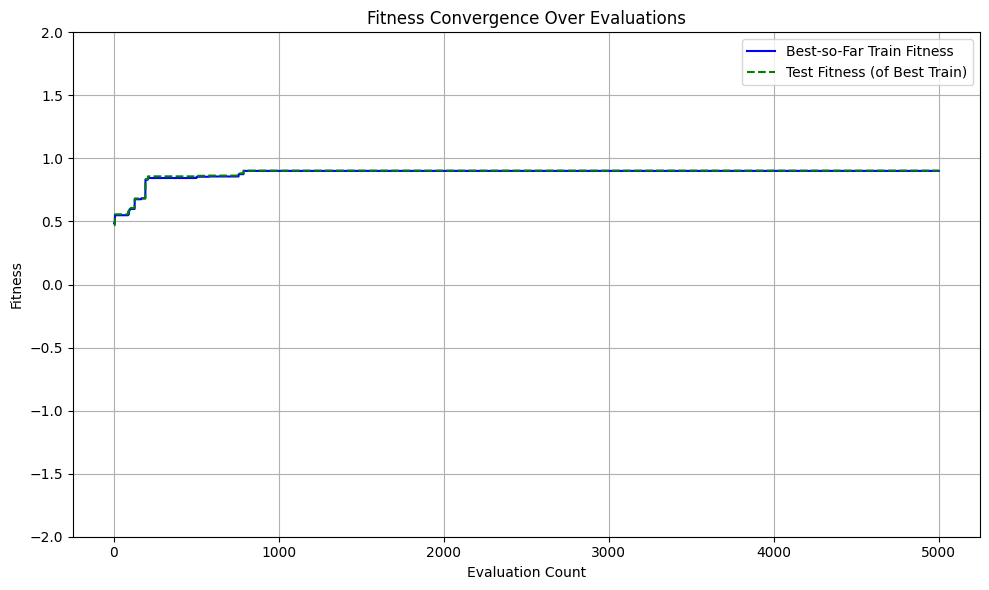

c:\Users\pauls\Bureau\Cours_2IS_M2\stage\pyCGP2.0\pycgp_finalclass\Genome.py:243: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


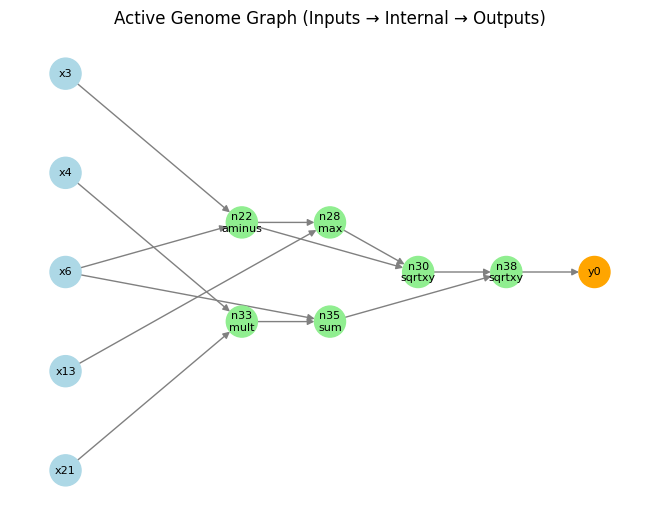

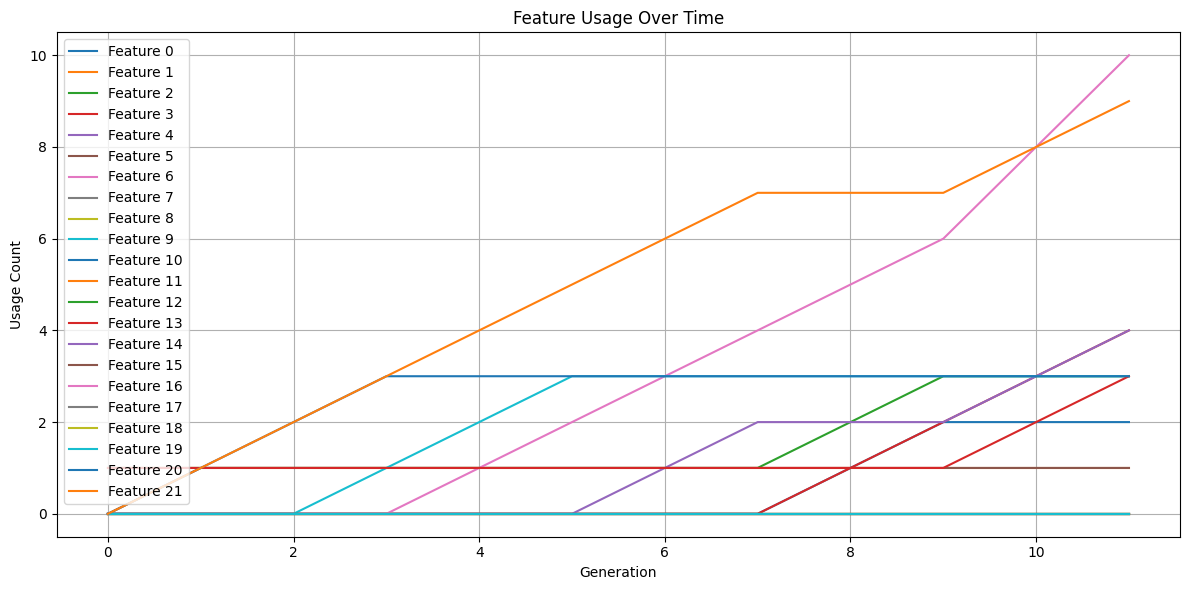

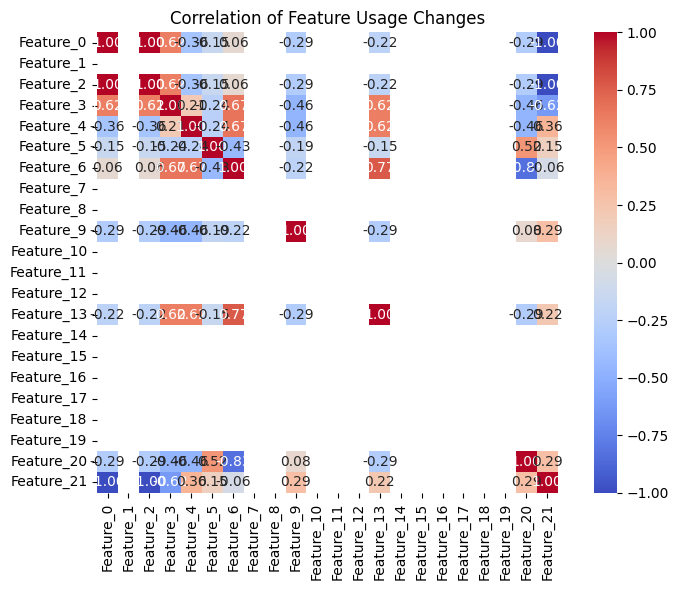

In [4]:
## Initialization of the CGP algorithm for regression ##

from pmlb import fetch_data
from sklearn.preprocessing import MinMaxScaler

# Selection of dataset
# We use a PMLB dataset for regression in this example
# You can change the dataset by modifying the fetch_data function parameters and putting the Dataset ID you want to use
gametes = fetch_data('mushroom')
# We save the dataset in a local directory
X, y = fetch_data('mushroom', return_X_y=True, local_cache_dir='./datasets')

# Float conversion data
X = X.astype(float)
y = y.astype(float)

# Standardize the data between -1 and 1
# This is important for the CGP algorithm to work properly
scaler = MinMaxScaler(feature_range=(-1, 1))
X = scaler.fit_transform(X)

# Here we define the evaluator for the CGP algorithm
# In this case we use a regression evaluator but you can use a multi-class classifier in the case of classification problems
evaluator = Binary_Classifier(X, y)

#Initialise config with the same number of inputs as features in the datasets, internal nodes around 20/30, outputs(number of classes)
CGP_config = CGPConfig(num_inputs=X.shape[1], num_nodes=30, num_outputs=1, input_node_chance=0.4, const_min=-1, const_max=1, function_set=functions)

# Define the mutation operator with the probabilities for each type of mutation
mutationcgp_golden = Golden_mutation(CGP_config,input_node_mutation_rate=0.2, function_mutation_rate=0.4, input_mutation_rate=0.5, const_mutation_rate=0.1,output_node_mutation_rate=0.5)

# Initialize the Evolution strategy with the number of offspring with the lam parameter
ES_cgp = ES(evaluator, lam=5,parent_factory=lambda: CGPGenome.create_genome(CGP_config),mutation = mutationcgp_golden, config= CGP_config)

# Run the ES for a chosen number of generations and early stopping in case of no improvement
# Put verbose=True to see the progress of the evolution
best_genome = ES_cgp.evolve(n_generations=1000, early_stopping=10000, early_switch= 5000 ,project_name= "1027_ESL", verbose=True)

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import pandas as pd

# --- Load the dataset ---
X, y = fetch_data('mushroom', return_X_y=True, local_cache_dir='./datasets')

# --- Split the dataset ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- Optional: Standardize features for models that benefit from it (SVM, KNN, Ridge, etc.) ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# --- Define classification models ---
models = {
    'Logistic Regression': LogisticRegression(max_iter=100000),
    'Ridge Classifier': RidgeClassifier(),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'Support Vector Classifier': SVC(),
    'KNN Classifier': KNeighborsClassifier()
}

# --- Evaluate accuracy for each model ---
results = {}

for name, model in models.items():
    if name in ['Support Vector Classifier', 'KNN Classifier', 'Ridge Classifier']:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    print(f"{name}: Accuracy = {acc:.4f}")

# --- Show sorted results ---
df_results = pd.DataFrame.from_dict(results, orient='index', columns=['Accuracy'])
df_results = df_results.sort_values('Accuracy', ascending=False)
print("\n=== Sorted Results ===")
print(df_results)


print("\n=== CGP result ===")
print(f"CGP: accuracy score = {evaluator.evaluate(best_genome)}")


Logistic Regression: Accuracy = 0.9514
Ridge Classifier: Accuracy = 0.9409
Random Forest: Accuracy = 1.0000
Gradient Boosting: Accuracy = 1.0000
Support Vector Classifier: Accuracy = 1.0000
KNN Classifier: Accuracy = 1.0000

=== Sorted Results ===
                           Accuracy
Gradient Boosting          1.000000
Random Forest              1.000000
Support Vector Classifier  1.000000
KNN Classifier             1.000000
Logistic Regression        0.951385
Ridge Classifier           0.940923

=== CGP result ===
CGP: accuracy score = (0.901061701800277, 0.9033846153846153)
